In [ ]:
pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.2 MB/s eta 0:00:00


Running Genetic Algorithm...


gen	nevals
0  	10    
1  	6     
2  	6     
3  	6     
4  	0     
5  	6     

Best Parameters from GA:
  Units   : 117
  Dropout : 0.4213
  LR      : 0.000100

Final training with best parameters...
Epoch 1/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - direction_accuracy: 0.5366 - direction_loss: 0.8780 - loss: 2.5816 - magnitude_loss: 3.4068 - val_direction_accuracy: 0.4746 - val_direction_loss: 0.8466 - val_loss: 1.0282 - val_magnitude_loss: 0.3900 - learning_rate: 1.0000e-04
Epoch 2/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - direction_accuracy: 0.5576 - direction_loss: 0.8605 - loss: 1.8687 - magnitude_loss: 2.0162 - val_direction_accuracy: 0.5424 - val_direction_loss: 0.8249 - val_loss: 0.9827 - val_magnitude_loss: 0.3318 - learning_rate: 1.0000e-04
Epoch 3/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - direction_accuracy: 0.6608 - direction_loss: 0.7524 - loss: 1.8400 - magnitude_loss: 2.1760 - val_direction_accuracy: 0.5424 - val_direction_loss: 0.8236 - val_loss: 0.9800 - val_

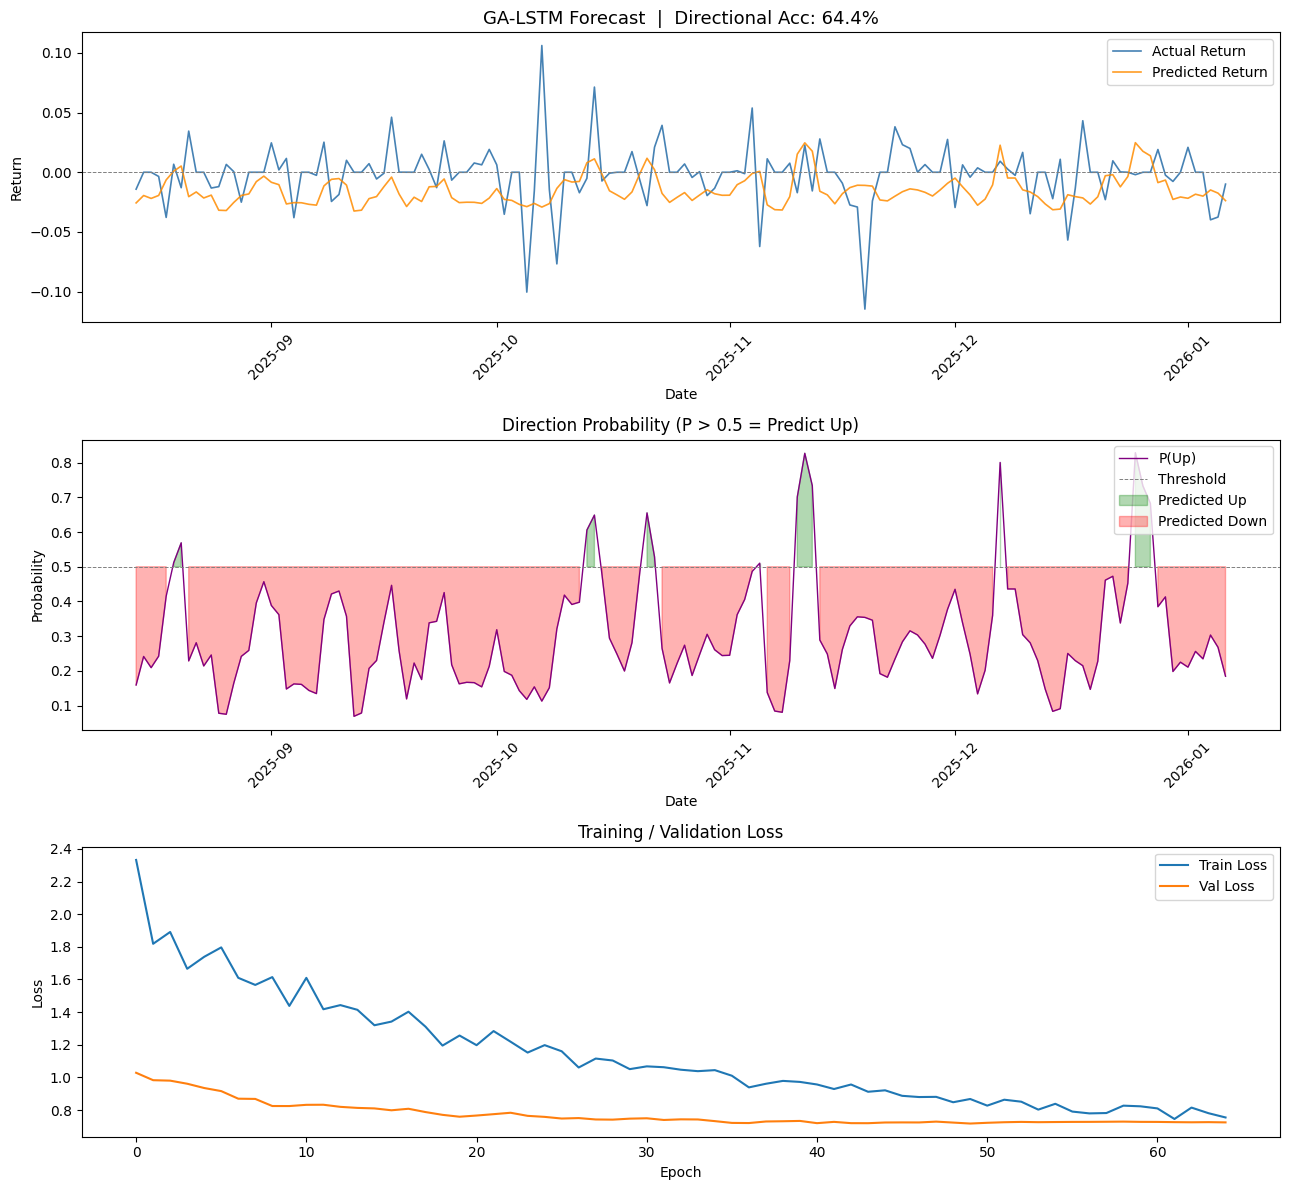

In [ ]:
# ================================
# GA-LSTM FORECAST
# Fixes flat prediction by:
# 1. Predicting direction (classification) not raw return
# 2. Rich feature engineering (momentum, volatility, lags)
# 3. GA tunes: units, dropout, lr
# ================================

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    Bidirectional, LayerNormalization, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from deap import base, creator, tools, algorithms


# ================================
# LOAD DATA
# ================================

file_path = "/content/dataset_title_post_full.xlsx"

df = pd.read_excel(file_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)


# ================================
# FEATURE ENGINEERING
# Add signals so the model has something meaningful to learn
# ================================

df['return_lag1']  = df['return'].shift(1)
df['return_lag2']  = df['return'].shift(2)
df['return_lag3']  = df['return'].shift(3)

# Momentum: cumulative return over past N days
df['momentum_3']   = df['return'].rolling(3).sum()
df['momentum_5']   = df['return'].rolling(5).sum()

# Volatility: rolling std of returns
df['volatility_3'] = df['return'].rolling(3).std()
df['volatility_5'] = df['return'].rolling(5).std()

# Sentiment lags
df['sent_lag1']    = df['sentiment'].shift(1)
df['sent_ma3']     = df['sentiment'].rolling(3).mean()

# Drop NaN rows from feature engineering
df = df.dropna().reset_index(drop=True)

dates = df['date']

FEATURE_COLS = [
    'return',
    'sentiment',
    'return_lag1', 'return_lag2', 'return_lag3',
    'momentum_3',  'momentum_5',
    'volatility_3','volatility_5',
    'sent_lag1',   'sent_ma3'
]

# Target: direction of next day's return (1 = up, 0 = down)
# We'll use this for classification, then scale by actual magnitude
y_direction = (df['return'].shift(-1) > 0).astype(int).values
y_magnitude = df['return'].shift(-1).values

# Remove last row (NaN target)
df      = df.iloc[:-1].reset_index(drop=True)
dates   = dates.iloc[:-1].reset_index(drop=True)
y_dir   = y_direction[:-1]
y_mag   = y_magnitude[:-1]

feature_data = df[FEATURE_COLS].values


# ================================
# NORMALIZATION
# ================================

feat_scaler = StandardScaler()
data_scaled = feat_scaler.fit_transform(feature_data)


# ================================
# CREATE SEQUENCES
# ================================

LOOKBACK = 5

def create_sequences(data, y_dir, y_mag, dates, lookback=5):
    X, Yd, Ym, D = [], [], [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        Yd.append(y_dir[i+lookback])
        Ym.append(y_mag[i+lookback])
        D.append(dates.iloc[i+lookback])
    return np.array(X), np.array(Yd), np.array(Ym), np.array(D)

X, y_d, y_m, seq_dates = create_sequences(
    data_scaled, y_dir, y_mag, dates, LOOKBACK
)


# ================================
# TRAIN / TEST SPLIT
# ================================

split = int(len(X) * 0.8)

X_train,      X_test      = X[:split],       X[split:]
y_train_dir,  y_test_dir  = y_d[:split],     y_d[split:]
y_train_mag,  y_test_mag  = y_m[:split],     y_m[split:]
dates_test                = seq_dates[split:]


# ================================
# MODEL BUILDER
# Dual-output: direction (sigmoid) + magnitude (linear)
# ================================

def build_model(units, dropout, lr):
    units = int(max(16, min(units, 128)))

    inp = Input(shape=(X_train.shape[1], X_train.shape[2]))

    x = Bidirectional(LSTM(units, return_sequences=True))(inp)
    x = LayerNormalization()(x)
    x = Dropout(dropout)(x)

    x = LSTM(max(8, units // 2))(x)
    x = LayerNormalization()(x)
    x = Dropout(dropout)(x)

    # Direction head (classification)
    dir_out = Dense(1, activation='sigmoid', name='direction')(x)

    # Magnitude head (regression)
    mag_out = Dense(1, activation='linear',  name='magnitude')(x)

    model = Model(inputs=inp, outputs=[dir_out, mag_out])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss={
            'direction': 'binary_crossentropy',
            'magnitude': 'mse'
        },
        loss_weights={
            'direction': 1.0,
            'magnitude': 0.5
        },
        metrics={
            'direction': 'accuracy'
        }
    )
    return model


# ================================
# FITNESS FUNCTION FOR GA
# Use directional accuracy (higher = better) as fitness
# GA minimizes, so return negative accuracy
# ================================

def evaluate_lstm(individual):
    units   = int(individual[0])
    dropout = float(individual[1])
    lr      = float(individual[2])

    units   = max(16,     min(units,   128))
    dropout = max(0.05,   min(dropout, 0.5))
    lr      = max(0.0001, min(lr,      0.01))

    try:
        model = build_model(units, dropout, lr)

        model.fit(
            X_train,
            {'direction': y_train_dir, 'magnitude': y_train_mag},
            epochs=20,
            batch_size=16,
            verbose=0
        )

        dir_pred, _ = model.predict(X_test, verbose=0)
        dir_pred_label = (dir_pred.flatten() > 0.5).astype(int)
        acc = accuracy_score(y_test_dir, dir_pred_label)

        return (-acc,)   # GA minimizes, so negate accuracy

    except Exception:
        return (0.0,)


# ================================
# GENETIC ALGORITHM SETUP
# ================================

# Guard against re-registration in Colab
for cls in ['FitnessMin', 'Individual']:
    if cls in creator.__dict__:
        delattr(creator, cls)

creator.create("FitnessMin", base.Fitness,  weights=(-1.0,))
creator.create("Individual", list,          fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("units",   random.randint,  16, 128)
toolbox.register("dropout", random.uniform,  0.05, 0.5)
toolbox.register("lr",      random.uniform,  0.0001, 0.01)

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (toolbox.units, toolbox.dropout, toolbox.lr),
    n=1
)

toolbox.register("population",  tools.initRepeat,    list, toolbox.individual)
toolbox.register("evaluate",    evaluate_lstm)
toolbox.register("mate",        tools.cxBlend,       alpha=0.5)
toolbox.register("mutate",      tools.mutGaussian,   mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select",      tools.selTournament, tournsize=3)


# ================================
# RUN GA
# ================================

print("Running Genetic Algorithm...")

population = toolbox.population(n=10)
hof        = tools.HallOfFame(1)

algorithms.eaSimple(
    population, toolbox,
    cxpb=0.5, mutpb=0.2, ngen=5,
    halloffame=hof,
    verbose=True
)

best_units   = int(max(16,    min(int(hof[0][0]),    128)))
best_dropout = float(max(0.05, min(float(hof[0][1]), 0.5)))
best_lr      = float(max(0.0001, min(float(hof[0][2]), 0.01)))

print(f"\nBest Parameters from GA:")
print(f"  Units   : {best_units}")
print(f"  Dropout : {best_dropout:.4f}")
print(f"  LR      : {best_lr:.6f}")


# ================================
# FINAL FULL TRAINING
# ================================

print("\nFinal training with best parameters...")

model = build_model(best_units, best_dropout, best_lr)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        verbose=1
    )
]

history = model.fit(
    X_train,
    {'direction': y_train_dir, 'magnitude': y_train_mag},
    epochs=150,
    batch_size=16,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)


# ================================
# PREDICT
# ================================

dir_pred_prob, mag_pred = model.predict(X_test, verbose=0)

dir_pred_prob = dir_pred_prob.flatten()
mag_pred      = mag_pred.flatten()

# Convert direction probability to signed prediction:
# probability > 0.5 → positive return, else negative
# Scale confidence: (prob - 0.5) * 2 gives range (-1, 1)
# Multiply by mean absolute return to get realistic magnitude
mean_abs_return = np.mean(np.abs(y_train_mag))
confidence      = (dir_pred_prob - 0.5) * 2   # range (-1, 1)
y_pred_final    = confidence * mean_abs_return * 3  # scale to realistic range

dir_labels      = (dir_pred_prob > 0.5).astype(int)


# ================================
# METRICS
# ================================

rmse    = np.sqrt(mean_squared_error(y_test_mag, y_pred_final))
mae     = mean_absolute_error(y_test_mag, y_pred_final)
dir_acc = accuracy_score(y_test_dir, dir_labels) * 100

print(f"\nTest Performance")
print(f"  RMSE              : {rmse:.6f}")
print(f"  MAE               : {mae:.6f}")
print(f"  Directional Acc   : {dir_acc:.1f}%")
print()
print(classification_report(y_test_dir, dir_labels, target_names=['Down','Up']))


# ================================
# PLOT
# ================================

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# --- Forecast ---
ax1 = axes[0]
ax1.plot(dates_test, y_test_mag,   label="Actual Return",    color='steelblue',  linewidth=1.2)
ax1.plot(dates_test, y_pred_final, label="Predicted Return", color='darkorange', linewidth=1.2, alpha=0.85)
ax1.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax1.set_title(f"GA-LSTM Forecast  |  Directional Acc: {dir_acc:.1f}%", fontsize=13)
ax1.set_xlabel("Date")
ax1.set_ylabel("Return")
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# --- Direction probability ---
ax2 = axes[1]
ax2.plot(dates_test, dir_pred_prob, color='purple', linewidth=1.0, label='P(Up)')
ax2.axhline(0.5, color='gray', linewidth=0.7, linestyle='--', label='Threshold')
ax2.fill_between(dates_test, 0.5, dir_pred_prob,
                 where=(dir_pred_prob > 0.5), alpha=0.3, color='green', label='Predicted Up')
ax2.fill_between(dates_test, dir_pred_prob, 0.5,
                 where=(dir_pred_prob < 0.5), alpha=0.3, color='red',   label='Predicted Down')
ax2.set_title("Direction Probability (P > 0.5 = Predict Up)")
ax2.set_xlabel("Date")
ax2.set_ylabel("Probability")
ax2.legend(loc='upper right')
ax2.tick_params(axis='x', rotation=45)

# --- Training loss ---
ax3 = axes[2]
ax3.plot(history.history['loss'],     label='Train Loss')
ax3.plot(history.history['val_loss'], label='Val Loss')
ax3.set_title("Training / Validation Loss")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Loss")
ax3.legend()

plt.tight_layout()
plt.savefig("ga_lstm_forecast.png", dpi=150)
plt.show()

Running Genetic Algorithm...
gen	nevals
0  	10    
1  	9     
2  	7     
3  	10    
4  	9     
5  	8     

Best Parameters from GA:
  Units   : 128
  Dropout : 0.3744
  LR      : 0.005015

Final training with best parameters...
Epoch 1/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - direction_accuracy: 0.5414 - direction_loss: 0.8610 - loss: 2.0411 - magnitude_loss: 2.3598 - val_direction_accuracy: 0.5763 - val_direction_loss: 0.7902 - val_loss: 0.8255 - val_magnitude_loss: 0.0633 - learning_rate: 0.0050
Epoch 2/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - direction_accuracy: 0.6463 - direction_loss: 0.6946 - loss: 0.9015 - magnitude_loss: 0.4140 - val_direction_accuracy: 0.6441 - val_direction_loss: 0.6455 - val_loss: 0.6655 - val_magnitude_loss: 0.0566 - learning_rate: 0.0050
Epoch 3/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - direction_accuracy: 0.6320 - direction_loss: 0.6644 - loss: 0.7456 - magnitude_loss: 0.1628 - val_direction_accuracy: 0.6441 - val_direction_loss: 0.7244 - va

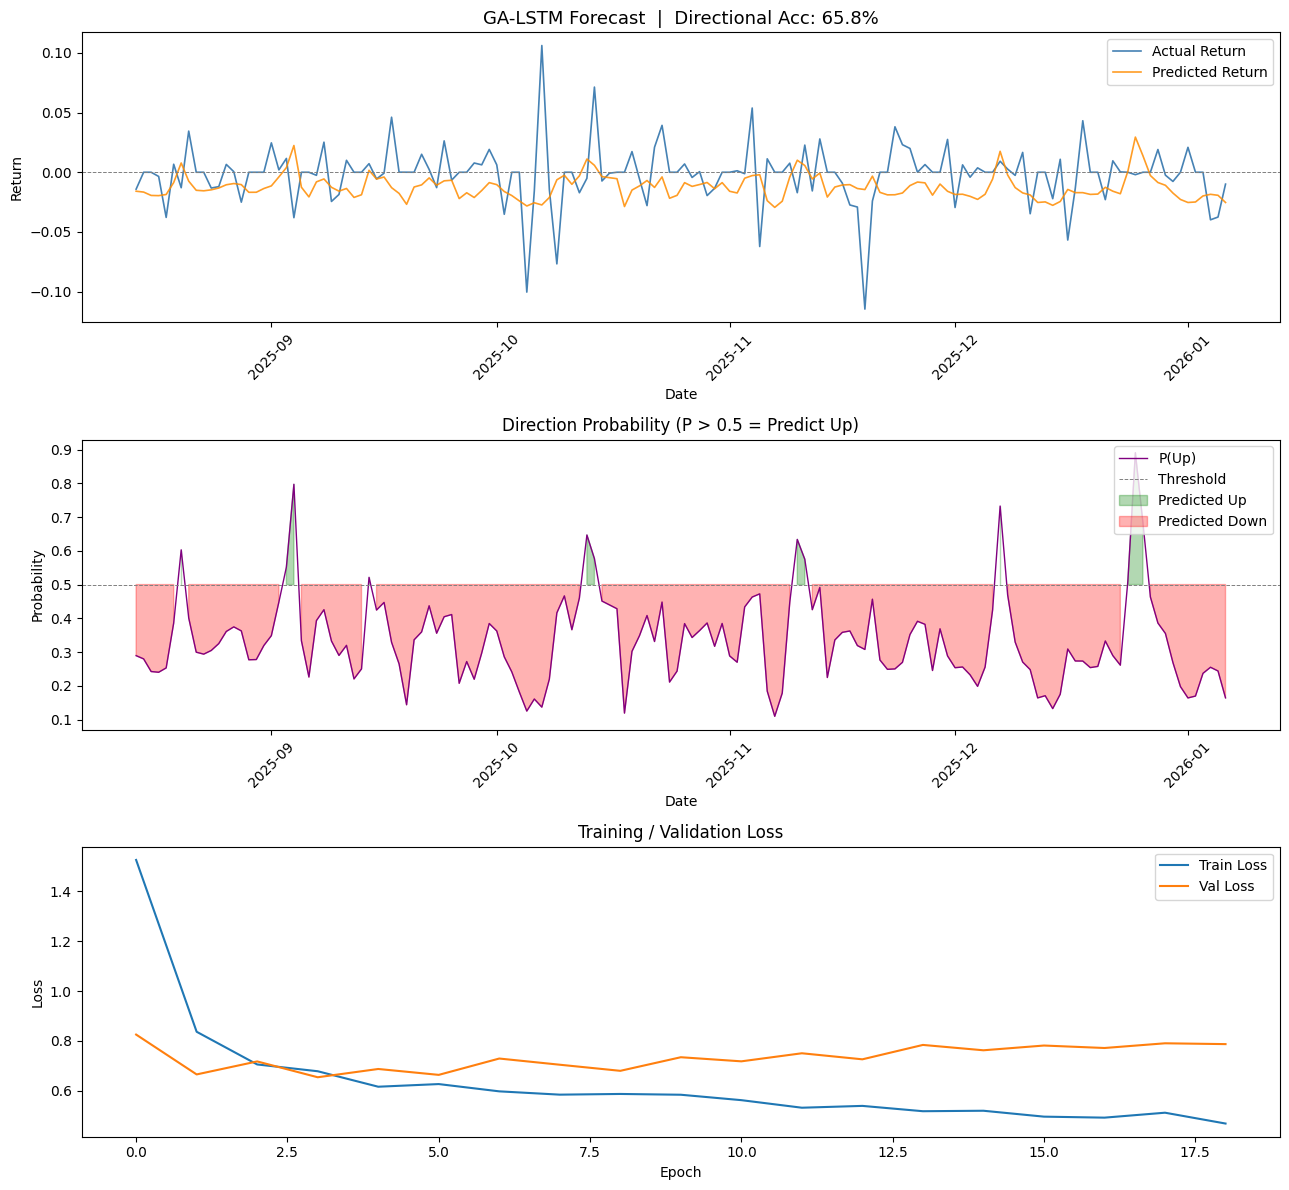

In [ ]:
# ================================
# GA-LSTM FORECAST
# Fixes flat prediction by:
# 1. Predicting direction (classification) not raw return
# 2. Rich feature engineering (momentum, volatility, lags)
# 3. GA tunes: units, dropout, lr
# ================================

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    Bidirectional, LayerNormalization, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from deap import base, creator, tools, algorithms


# ================================
# LOAD DATA
# ================================

file_path = "/content/dataset_title_only_full.xlsx"

df = pd.read_excel(file_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)


# ================================
# FEATURE ENGINEERING
# Add signals so the model has something meaningful to learn
# ================================

df['return_lag1']  = df['return'].shift(1)
df['return_lag2']  = df['return'].shift(2)
df['return_lag3']  = df['return'].shift(3)

# Momentum: cumulative return over past N days
df['momentum_3']   = df['return'].rolling(3).sum()
df['momentum_5']   = df['return'].rolling(5).sum()

# Volatility: rolling std of returns
df['volatility_3'] = df['return'].rolling(3).std()
df['volatility_5'] = df['return'].rolling(5).std()

# Sentiment lags
df['sent_lag1']    = df['sentiment'].shift(1)
df['sent_ma3']     = df['sentiment'].rolling(3).mean()

# Drop NaN rows from feature engineering
df = df.dropna().reset_index(drop=True)

dates = df['date']

FEATURE_COLS = [
    'return',
    'sentiment',
    'return_lag1', 'return_lag2', 'return_lag3',
    'momentum_3',  'momentum_5',
    'volatility_3','volatility_5',
    'sent_lag1',   'sent_ma3'
]

# Target: direction of next day's return (1 = up, 0 = down)
# We'll use this for classification, then scale by actual magnitude
y_direction = (df['return'].shift(-1) > 0).astype(int).values
y_magnitude = df['return'].shift(-1).values

# Remove last row (NaN target)
df      = df.iloc[:-1].reset_index(drop=True)
dates   = dates.iloc[:-1].reset_index(drop=True)
y_dir   = y_direction[:-1]
y_mag   = y_magnitude[:-1]

feature_data = df[FEATURE_COLS].values


# ================================
# NORMALIZATION
# ================================

feat_scaler = StandardScaler()
data_scaled = feat_scaler.fit_transform(feature_data)


# ================================
# CREATE SEQUENCES
# ================================

LOOKBACK = 5

def create_sequences(data, y_dir, y_mag, dates, lookback=5):
    X, Yd, Ym, D = [], [], [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        Yd.append(y_dir[i+lookback])
        Ym.append(y_mag[i+lookback])
        D.append(dates.iloc[i+lookback])
    return np.array(X), np.array(Yd), np.array(Ym), np.array(D)

X, y_d, y_m, seq_dates = create_sequences(
    data_scaled, y_dir, y_mag, dates, LOOKBACK
)


# ================================
# TRAIN / TEST SPLIT
# ================================

split = int(len(X) * 0.8)

X_train,      X_test      = X[:split],       X[split:]
y_train_dir,  y_test_dir  = y_d[:split],     y_d[split:]
y_train_mag,  y_test_mag  = y_m[:split],     y_m[split:]
dates_test                = seq_dates[split:]


# ================================
# MODEL BUILDER
# Dual-output: direction (sigmoid) + magnitude (linear)
# ================================

def build_model(units, dropout, lr):
    units = int(max(16, min(units, 128)))

    inp = Input(shape=(X_train.shape[1], X_train.shape[2]))

    x = Bidirectional(LSTM(units, return_sequences=True))(inp)
    x = LayerNormalization()(x)
    x = Dropout(dropout)(x)

    x = LSTM(max(8, units // 2))(x)
    x = LayerNormalization()(x)
    x = Dropout(dropout)(x)

    # Direction head (classification)
    dir_out = Dense(1, activation='sigmoid', name='direction')(x)

    # Magnitude head (regression)
    mag_out = Dense(1, activation='linear',  name='magnitude')(x)

    model = Model(inputs=inp, outputs=[dir_out, mag_out])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss={
            'direction': 'binary_crossentropy',
            'magnitude': 'mse'
        },
        loss_weights={
            'direction': 1.0,
            'magnitude': 0.5
        },
        metrics={
            'direction': 'accuracy'
        }
    )
    return model


# ================================
# FITNESS FUNCTION FOR GA
# Use directional accuracy (higher = better) as fitness
# GA minimizes, so return negative accuracy
# ================================

def evaluate_lstm(individual):
    units   = int(individual[0])
    dropout = float(individual[1])
    lr      = float(individual[2])

    units   = max(16,     min(units,   128))
    dropout = max(0.05,   min(dropout, 0.5))
    lr      = max(0.0001, min(lr,      0.01))

    try:
        model = build_model(units, dropout, lr)

        model.fit(
            X_train,
            {'direction': y_train_dir, 'magnitude': y_train_mag},
            epochs=20,
            batch_size=16,
            verbose=0
        )

        dir_pred, _ = model.predict(X_test, verbose=0)
        dir_pred_label = (dir_pred.flatten() > 0.5).astype(int)
        acc = accuracy_score(y_test_dir, dir_pred_label)

        return (-acc,)   # GA minimizes, so negate accuracy

    except Exception:
        return (0.0,)


# ================================
# GENETIC ALGORITHM SETUP
# ================================

# Guard against re-registration in Colab
for cls in ['FitnessMin', 'Individual']:
    if cls in creator.__dict__:
        delattr(creator, cls)

creator.create("FitnessMin", base.Fitness,  weights=(-1.0,))
creator.create("Individual", list,          fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("units",   random.randint,  16, 128)
toolbox.register("dropout", random.uniform,  0.05, 0.5)
toolbox.register("lr",      random.uniform,  0.0001, 0.01)

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (toolbox.units, toolbox.dropout, toolbox.lr),
    n=1
)

toolbox.register("population",  tools.initRepeat,    list, toolbox.individual)
toolbox.register("evaluate",    evaluate_lstm)
toolbox.register("mate",        tools.cxBlend,       alpha=0.5)
toolbox.register("mutate",      tools.mutGaussian,   mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select",      tools.selTournament, tournsize=3)


# ================================
# RUN GA
# ================================

print("Running Genetic Algorithm...")

population = toolbox.population(n=10)
hof        = tools.HallOfFame(1)

algorithms.eaSimple(
    population, toolbox,
    cxpb=0.5, mutpb=0.2, ngen=5,
    halloffame=hof,
    verbose=True
)

best_units   = int(max(16,    min(int(hof[0][0]),    128)))
best_dropout = float(max(0.05, min(float(hof[0][1]), 0.5)))
best_lr      = float(max(0.0001, min(float(hof[0][2]), 0.01)))

print(f"\nBest Parameters from GA:")
print(f"  Units   : {best_units}")
print(f"  Dropout : {best_dropout:.4f}")
print(f"  LR      : {best_lr:.6f}")


# ================================
# FINAL FULL TRAINING
# ================================

print("\nFinal training with best parameters...")

model = build_model(best_units, best_dropout, best_lr)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        verbose=1
    )
]

history = model.fit(
    X_train,
    {'direction': y_train_dir, 'magnitude': y_train_mag},
    epochs=150,
    batch_size=16,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)


# ================================
# PREDICT
# ================================

dir_pred_prob, mag_pred = model.predict(X_test, verbose=0)

dir_pred_prob = dir_pred_prob.flatten()
mag_pred      = mag_pred.flatten()

# Convert direction probability to signed prediction:
# probability > 0.5 → positive return, else negative
# Scale confidence: (prob - 0.5) * 2 gives range (-1, 1)
# Multiply by mean absolute return to get realistic magnitude
mean_abs_return = np.mean(np.abs(y_train_mag))
confidence      = (dir_pred_prob - 0.5) * 2   # range (-1, 1)
y_pred_final    = confidence * mean_abs_return * 3  # scale to realistic range

dir_labels      = (dir_pred_prob > 0.5).astype(int)


# ================================
# METRICS
# ================================

rmse    = np.sqrt(mean_squared_error(y_test_mag, y_pred_final))
mae     = mean_absolute_error(y_test_mag, y_pred_final)
dir_acc = accuracy_score(y_test_dir, dir_labels) * 100

print(f"\nTest Performance")
print(f"  RMSE              : {rmse:.6f}")
print(f"  MAE               : {mae:.6f}")
print(f"  Directional Acc   : {dir_acc:.1f}%")
print()
print(classification_report(y_test_dir, dir_labels, target_names=['Down','Up']))


# ================================
# PLOT
# ================================

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# --- Forecast ---
ax1 = axes[0]
ax1.plot(dates_test, y_test_mag,   label="Actual Return",    color='steelblue',  linewidth=1.2)
ax1.plot(dates_test, y_pred_final, label="Predicted Return", color='darkorange', linewidth=1.2, alpha=0.85)
ax1.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax1.set_title(f"GA-LSTM Forecast  |  Directional Acc: {dir_acc:.1f}%", fontsize=13)
ax1.set_xlabel("Date")
ax1.set_ylabel("Return")
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# --- Direction probability ---
ax2 = axes[1]
ax2.plot(dates_test, dir_pred_prob, color='purple', linewidth=1.0, label='P(Up)')
ax2.axhline(0.5, color='gray', linewidth=0.7, linestyle='--', label='Threshold')
ax2.fill_between(dates_test, 0.5, dir_pred_prob,
                 where=(dir_pred_prob > 0.5), alpha=0.3, color='green', label='Predicted Up')
ax2.fill_between(dates_test, dir_pred_prob, 0.5,
                 where=(dir_pred_prob < 0.5), alpha=0.3, color='red',   label='Predicted Down')
ax2.set_title("Direction Probability (P > 0.5 = Predict Up)")
ax2.set_xlabel("Date")
ax2.set_ylabel("Probability")
ax2.legend(loc='upper right')
ax2.tick_params(axis='x', rotation=45)

# --- Training loss ---
ax3 = axes[2]
ax3.plot(history.history['loss'],     label='Train Loss')
ax3.plot(history.history['val_loss'], label='Val Loss')
ax3.set_title("Training / Validation Loss")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Loss")
ax3.legend()

plt.tight_layout()
plt.savefig("ga_lstm_forecast.png", dpi=150)
plt.show()